# Text-to-Brain Metrics v2

This notebook evaluates only the text-to-brain direction from the old metrics v2 notebook. It reports Pearson correlation, Spearman correlation, percentile Dice, spin-test p-values when dependencies are available, and threshold-sensitivity plots.

To run the full available test set, set `MAX_T2B = None`. For fast iteration, lower `SPIN_TEST_N_PERM` or set `SPIN_USE_NEUROMAPS = False`.

In [1]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from scipy.stats import spearmanr

from neurovlm import NeuroVLM
from neurovlm.data import load_dataset, load_latent, load_masker
from neurovlm.metrics import (
    pearson_correlation,
    dice_percentile,
    nct_dice_spin_test_surface,
    mni152_to_fsaverage_arrays,
)

In [2]:
MAX_T2B = 50          # set to None for full available test set
RUN_NETWORKS = True
RUN_PUBMED = True
RUN_NEUROVAULT = True

DICE_PCT = 90
DICE_SENSITIVITY_PCTS = [80, 85, 90, 95]
SPIN_USE_NEUROMAPS = True
SPIN_TEST_N_PERM = 1000
SPIN_TEST_RANDOM_STATE = 13
SPIN_FSAVERAGE_DENSITY = "41k"
SPIN_TRANSFORM_METHOD = "linear"

OUTPUT_DIR = Path("docs/03_evaluation/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
nvlm = NeuroVLM()
masker = load_masker()
print("Ready.")

Ready.


In [4]:
def resolve_network_test_set_path():
    candidates = [
        Path("network_test_set_labels.csv"),
        Path("docs/03_evaluation/network_test_set_labels.csv"),
        Path.cwd() / "network_test_set_labels.csv",
        Path.cwd() / "docs/03_evaluation/network_test_set_labels.csv",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "Could not find network_test_set_labels.csv. Run "
        "23_create_networks_test_set_csv.ipynb first, or set NETWORK_TEST_SET_PATH "
        "to the CSV location. Checked: " + ", ".join(str(c) for c in candidates)
    )


NETWORK_TEST_SET_PATH = resolve_network_test_set_path()
network_labels_df = pd.read_csv(NETWORK_TEST_SET_PATH)
network_labels_df = network_labels_df[network_labels_df["network_key"] != "unknown"].copy()

# One row per canonical network, derived from the network test-set CSV.
network_info = (
    network_labels_df
    .sort_values(["network_key", "raw_network_label"])
    .groupby("network_key", as_index=False)
    .agg(
        display=("network_name", "first"),
        short_definition=("short_definition", "first"),
        long_definition=("long_definition", "first"),
        mapped_terms=("mapped_terms", "first"),
        raw_aliases=("raw_network_label", lambda s: "; ".join(sorted(set(map(str, s))))),
    )
)

DISPLAY_TO_KEY = dict(zip(network_info["display"], network_info["network_key"]))
KEY_TO_DISPLAY = dict(zip(network_info["network_key"], network_info["display"]))
SHORT_LABELS = dict(zip(network_info["display"], network_info["short_definition"]))
LONG_LABELS = dict(zip(network_info["display"], network_info["long_definition"]))

print(f"Loaded {len(network_info)} canonical network labels from {NETWORK_TEST_SET_PATH.resolve()}")
display(network_info[["network_key", "display", "short_definition"]])

Loaded 8 canonical network labels from /Users/borng/code/lab_work/neurovlm/docs/03_evaluation/network_test_set_labels.csv


,network_key,display,short_definition
0,attention,Attention,Dorsal attention network for selective attenti...
1,auditory,Auditory,"Auditory network for auditory perception, soun..."
2,cingulo_opercular,Cingulo-Opercular,Cingulo-opercular/salience network for salienc...
3,default_mode,Default Mode,Default mode network for self-referential thou...
4,frontoparietal_control,Frontoparietal Control,Frontoparietal control network for executive c...
5,language,Language,"Language network for speech comprehension, spe..."
6,motor,Motor,"Sensorimotor network for movement planning, vo..."
7,visual,Visual,"Visual network for visual perception, object r..."


In [5]:
_LABEL_TO_DU = {
    "Language": "LANG",
    "Auditory": "AUD",
    "Default Mode": "DN-A",
    "Frontoparietal Control": "FPN-A",
    "Attention": "dATN-A",
    "Visual": "VIS-C",
    "Motor": "SMOT-A",
    "Cingulo-Opercular": "CG-OP",
}

def _normalize_expected_text(text: str) -> str:
    return re.sub(r"\s+", " ", str(text or "")).strip()

all_net_latents = load_latent("networks_neuro")
du = all_net_latents["Du"]
networks_data = {
    label: {
        "latent": du[du_key],
        "short_gt": _normalize_expected_text(SHORT_LABELS[label]),
        "long_gt": _normalize_expected_text(LONG_LABELS[label]),
        "network_key": DISPLAY_TO_KEY[label],
    }
    for label, du_key in _LABEL_TO_DU.items()
    if du_key in du and label in DISPLAY_TO_KEY
}
print(f"Networks loaded: {list(networks_data)}")

Networks loaded: ['Language', 'Auditory', 'Default Mode', 'Frontoparietal Control', 'Attention', 'Visual', 'Motor', 'Cingulo-Opercular']


In [6]:
df_pubs = load_dataset("pubmed_text")
if "split" in df_pubs.columns:
    df_test = df_pubs[df_pubs["split"] == "test"].reset_index(drop=True)
else:
    print("WARNING: no split column found; using full PubMed table as a test proxy.")
    df_test = df_pubs.copy().reset_index(drop=True)

_pmid_col = "pmid" if "pmid" in df_test.columns else df_test.columns[0]
_title_col = "name" if "name" in df_test.columns else "title"
_abstract_col = "description" if "description" in df_test.columns else "abstract"

pubmed_latents, pubmed_pmids = load_latent("pubmed_images")
pubmed_pmids = np.asarray(pubmed_pmids)
mask = np.isin(pubmed_pmids, df_test[_pmid_col].values)
aligned_latents = pubmed_latents[mask]
aligned_pmids = pubmed_pmids[mask]
pmid_to_row = df_test.set_index(_pmid_col)

pubmed_data = []
for i, pmid in enumerate(aligned_pmids):
    if pmid not in pmid_to_row.index:
        continue
    row = pmid_to_row.loc[pmid]
    pubmed_data.append({
        "pmid": pmid,
        "latent": aligned_latents[i],
        "short_gt": str(row[_title_col]) if _title_col in row.index else "",
        "long_gt": str(row[_abstract_col]) if _abstract_col in row.index else "",
    })

pubmed_eval = pubmed_data[:MAX_T2B] if MAX_T2B else pubmed_data
print(f"PubMed samples: {len(pubmed_eval)} / {len(pubmed_data)}")

PubMed samples: 50 / 29868


In [7]:
df_nv = load_dataset("neurovault_text")
df_nv_meta = load_dataset("neurovault_images_meta")
nv_latents = load_latent("neurovault_images")

_doi_pub = "doi" if "doi" in df_nv.columns else df_nv.columns[0]
_doi_meta = "doi" if "doi" in df_nv_meta.columns else df_nv_meta.columns[0]
_title_nv = "title" if "title" in df_nv.columns else df_nv.columns[1]
_abs_nv = "abstract" if "abstract" in df_nv.columns else df_nv.columns[2]

neurovault_data = []
for _, pub_row in df_nv.iterrows():
    doi = pub_row[_doi_pub]
    img_indices = np.where((df_nv_meta[_doi_meta] == doi).values)[0]
    if len(img_indices) == 0 or img_indices[0] >= len(nv_latents):
        continue
    neurovault_data.append({
        "doi": doi,
        "latent": nv_latents[int(img_indices[0])],
        "short_gt": str(pub_row[_title_nv]),
        "long_gt": str(pub_row[_abs_nv]),
    })

neurovault_eval = neurovault_data[:MAX_T2B] if MAX_T2B else neurovault_data
print(f"NeuroVault samples: {len(neurovault_eval)} / {len(neurovault_data)}")

NeuroVault samples: 50 / 312


In [8]:
def run_t2b(name, text_input, true_latent):
    try:
        gen_result = nvlm.text(text_input).to_brain(head="mse")
        nifti_pred = gen_result.to_nifti(index=0)
        brain_pred = masker.transform(nifti_pred).ravel().astype("float32")

        dec = gen_result.decoder
        dec_device = next(dec.parameters()).device
        lat = true_latent
        if lat.dim() == 1:
            lat = lat.unsqueeze(0)
        with torch.no_grad():
            brain_true = torch.sigmoid(dec(lat.to(dec_device))).squeeze(0).cpu().numpy()
        nifti_true = masker.inverse_transform(brain_true.reshape(1, -1))

        pearson_r = float(pearson_correlation(brain_true, brain_pred))
        spearman_rho, _ = spearmanr(brain_true.ravel(), brain_pred.ravel())
        dice_val = dice_percentile(brain_pred, brain_true, pct=DICE_PCT)
        dice_method = "volume_masker_percentile"
        pred_lh = pred_rh = true_lh = true_rh = None
        spin_p_value = np.nan
        spin_method = "not_run"
        spin_significant = False

        if SPIN_USE_NEUROMAPS:
            try:
                pred_lh, pred_rh = mni152_to_fsaverage_arrays(nifti_pred, density=SPIN_FSAVERAGE_DENSITY, method=SPIN_TRANSFORM_METHOD)
                true_lh, true_rh = mni152_to_fsaverage_arrays(nifti_true, density=SPIN_FSAVERAGE_DENSITY, method=SPIN_TRANSFORM_METHOD)
                nct = nct_dice_spin_test_surface(
                    pred_lh, pred_rh, true_lh, true_rh,
                    pct=DICE_PCT,
                    n_perm=SPIN_TEST_N_PERM,
                    random_state=SPIN_TEST_RANDOM_STATE,
                    density=SPIN_FSAVERAGE_DENSITY,
                )
                dice_val = nct.dice_pct
                dice_method = "surface_fsaverage_percentile_nct"
                spin_p_value = nct.spin_p_value
                spin_method = nct.spin_method
                spin_significant = nct.spin_significant
            except ImportError as e:
                spin_method = f"not_run_missing_dependency:{e.name}"
            except Exception as e:
                spin_method = f"not_run_nct_error:{type(e).__name__}: {e}"

        return {
            "name": name,
            "text_input": text_input[:120],
            "pearson_r": pearson_r,
            "spearman_rho": float(spearman_rho),
            f"dice_pct{DICE_PCT}": float(dice_val),
            "dice_method": dice_method,
            "spin_p_value": float(spin_p_value) if np.isfinite(spin_p_value) else np.nan,
            "spin_significant": bool(spin_significant),
            "spin_method": spin_method,
            "_brain_pred": brain_pred,
            "_brain_true": brain_true,
            "_pred_lh": pred_lh,
            "_pred_rh": pred_rh,
            "_true_lh": true_lh,
            "_true_rh": true_rh,
        }
    except Exception as e:
        print(f"[T2B error] {name}: {type(e).__name__}: {e}")
        return None

In [9]:
t2b_frames = []

if RUN_NETWORKS:
    records = []
    for net_name, d in tqdm(networks_data.items(), desc="Networks T2B"):
        rec = run_t2b(net_name, d["long_gt"], d["latent"])
        if rec is not None:
            records.append(rec)
    t2b_net_df = pd.DataFrame(records)
    t2b_net_df["dataset"] = "networks"
    t2b_frames.append(t2b_net_df)

if RUN_PUBMED:
    records = []
    for d in tqdm(pubmed_eval, desc="PubMed T2B"):
        rec = run_t2b(str(d["pmid"]), d["short_gt"] + " [SEP] " + d["long_gt"], d["latent"])
        if rec is not None:
            records.append(rec)
    t2b_pubmed_df = pd.DataFrame(records)
    t2b_pubmed_df["dataset"] = "pubmed"
    t2b_frames.append(t2b_pubmed_df)

if RUN_NEUROVAULT:
    records = []
    for d in tqdm(neurovault_eval, desc="NeuroVault T2B"):
        rec = run_t2b(str(d["doi"]), d["short_gt"] + " [SEP] " + d["long_gt"], d["latent"])
        if rec is not None:
            records.append(rec)
    t2b_nv_df = pd.DataFrame(records)
    t2b_nv_df["dataset"] = "neurovault"
    t2b_frames.append(t2b_nv_df)

t2b_all = pd.concat(t2b_frames, ignore_index=True)
t2b_all.to_csv(OUTPUT_DIR / "text_to_brain_metrics_v2.csv", index=False)
t2b_all.head()

Networks T2B:   0%|          | 0/8 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.
/Users/borng/code/lab_work/neurovlm/.conda/lib/python3.12/site-packages/neuromaps/datasets/utils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


PubMed T2B:   0%|          | 0/50 [00:00<?, ?it/s]

NeuroVault T2B:   0%|          | 0/50 [00:00<?, ?it/s]

,name,text_input,pearson_r,spearman_rho,dice_pct90,dice_method,spin_p_value,spin_significant,spin_method,_brain_pred,_brain_true,_pred_lh,_pred_rh,_true_lh,_true_rh,dataset
0,Language,The language network includes inferior frontal...,0.555781,0.496984,0.551324,surface_fsaverage_percentile_nct,0.000999,True,neuromaps_mni152_to_fsaverage_41k+brainspace_spin,"[2.219853e-06, 0.22896773, 0.21519034, 5.08568...","[2.2573904e-14, 0.13919882, 0.20989029, 4.1316...","[0.013426343, 0.014209338, 0.03084008, 0.02221...","[0.01856246, 0.05032958, 0.02649027, 0.0176406...","[2.5227251e-05, 3.37727e-05, 0.000188088, 0.00...","[0.000493713, 0.0006641709, 8.8872766e-05, 9.7...",networks
1,Auditory,The auditory network includes primary auditory...,0.642937,0.699131,0.802026,surface_fsaverage_percentile_nct,0.000999,True,neuromaps_mni152_to_fsaverage_41k+brainspace_spin,"[2.0208913e-06, 0.17914301, 0.17343724, 4.1845...","[1.966833e-25, 0.00014512522, 0.0003801403, 5....","[0.011207284, 0.0050929696, 0.031968236, 0.015...","[0.014900311, 0.019930176, 0.03411155, 0.00880...","[9.544638e-11, 7.386878e-08, 9.257005e-10, 2.7...","[6.825629e-09, 6.751385e-08, 4.592297e-06, 4.4...",networks
2,Default Mode,The default mode network includes medial prefr...,0.564739,0.619610,0.516172,surface_fsaverage_percentile_nct,0.000999,True,neuromaps_mni152_to_fsaverage_41k+brainspace_spin,"[1.5073856e-06, 0.041484848, 0.039975416, 3.24...","[3.2402536e-15, 1.001952e-05, 4.1408484e-06, 7...","[0.011652597, 0.01869179, 0.023020802, 0.05054...","[0.020478254, 0.042466007, 0.0093206465, 0.030...","[5.679743e-07, 4.5748304e-05, 4.8502046e-05, 0...","[3.6278325e-05, 0.0002937558, 5.2181883e-07, 0...",networks
3,Frontoparietal Control,The frontoparietal control network includes do...,0.609310,0.798546,0.642134,surface_fsaverage_percentile_nct,0.000999,True,neuromaps_mni152_to_fsaverage_41k+brainspace_spin,"[1.8654026e-06, 0.030999197, 0.033307318, 3.18...","[2.0760444e-16, 0.0035830748, 0.009125289, 1.0...","[0.02467221, 0.041872866, 0.040508874, 0.05325...","[0.03284924, 0.12691672, 0.015785513, 0.092138...","[1.5301384e-05, 0.0010412799, 0.00032881874, 0...","[0.00040518842, 0.1183145, 1.4460969e-05, 0.01...",networks
4,Attention,The attention network emphasizes dorsal attent...,0.455451,0.706500,0.497132,surface_fsaverage_percentile_nct,0.000999,True,neuromaps_mni152_to_fsaverage_41k+brainspace_spin,"[7.3164216e-07, 0.016863339, 0.020423226, 1.60...","[3.6595665e-14, 0.00047142323, 0.0012996199, 1...","[0.023461886, 0.053728897, 0.03170016, 0.01808...","[0.031037888, 0.10765148, 0.013348333, 0.02890...","[0.0014461773, 0.37985215, 3.740727e-05, 0.000...","[0.004275755, 0.12439357, 0.0022526025, 0.0010...",networks


In [10]:
dice_col = f"dice_pct{DICE_PCT}"
metric_cols = ["pearson_r", "spearman_rho", dice_col, "spin_p_value"]
summary = t2b_all.groupby("dataset")[metric_cols].agg(["mean", "std", "count"]).round(3)
display(summary)
display(t2b_all.groupby("dataset")["spin_significant"].sum().rename("n_spin_p_lt_0_05"))
display(t2b_all.groupby(["dataset", "spin_method"]).size().rename("n"))

pearson_r              spearman_rho              dice_pct90         \
                mean    std count         mean    std count       mean    std   
dataset                                                                         
networks       0.522  0.114     8        0.635  0.124     8      0.591  0.151   
neurovault     0.152  0.161    50        0.377  0.213    50      0.202  0.161   
pubmed         0.393  0.192    50        0.530  0.190    50      0.362  0.191   

                 spin_p_value               
           count         mean    std count  
dataset                                     
networks       8        0.002  0.001     8  
neurovault    50        0.315  0.346    50  
pubmed        50        0.094  0.201    50

dataset
networks       8
neurovault    19
pubmed        39
Name: n_spin_p_lt_0_05, dtype: int64

dataset     spin_method                                      
networks    neuromaps_mni152_to_fsaverage_41k+brainspace_spin     8
neurovault  neuromaps_mni152_to_fsaverage_41k+brainspace_spin    50
pubmed      neuromaps_mni152_to_fsaverage_41k+brainspace_spin    50
Name: n, dtype: int64

In [11]:
def _sensitivity_rows_for_df(df, dataset, pcts=DICE_SENSITIVITY_PCTS):
    rows = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"{dataset} Dice sensitivity"):
        for pct in pcts:
            has_surface = all(row.get(k) is not None for k in ["_pred_lh", "_pred_rh", "_true_lh", "_true_rh"])
            spin_p = np.nan
            spin_sig = False
            method = "volume_masker_percentile"
            if has_surface:
                try:
                    nct = nct_dice_spin_test_surface(
                        row["_pred_lh"], row["_pred_rh"], row["_true_lh"], row["_true_rh"],
                        pct=pct, n_perm=SPIN_TEST_N_PERM, random_state=SPIN_TEST_RANDOM_STATE,
                        density=SPIN_FSAVERAGE_DENSITY,
                    )
                    dice_val = nct.dice_pct
                    spin_p = nct.spin_p_value
                    spin_sig = nct.spin_significant
                    method = "surface_fsaverage_percentile_nct"
                except Exception:
                    dice_val = dice_percentile(row["_brain_pred"], row["_brain_true"], pct=pct)
            else:
                dice_val = dice_percentile(row["_brain_pred"], row["_brain_true"], pct=pct)
            rows.append({
                "dataset": dataset,
                "sample": row["name"],
                "pct": pct,
                "top_fraction": (100 - pct) / 100,
                "dice": float(dice_val),
                "spin_p_value": float(spin_p) if np.isfinite(spin_p) else np.nan,
                "spin_significant": bool(spin_sig),
                "method": method,
            })
    return rows

sensitivity_records = []
for dataset, sub in t2b_all.groupby("dataset"):
    sensitivity_records.extend(_sensitivity_rows_for_df(sub.reset_index(drop=True), dataset))
t2b_sensitivity_df = pd.DataFrame(sensitivity_records)
display(t2b_sensitivity_df.groupby(["dataset", "pct"]).agg(dice_mean=("dice", "mean"), dice_std=("dice", "std"), sig_rate=("spin_significant", "mean"), n=("sample", "count")).round(3))

networks Dice sensitivity:   0%|          | 0/8 [00:00<?, ?it/s]

neurovault Dice sensitivity:   0%|          | 0/50 [00:00<?, ?it/s]

pubmed Dice sensitivity:   0%|          | 0/50 [00:00<?, ?it/s]

dice_mean  dice_std  sig_rate   n
dataset    pct                                   
networks   80       0.648     0.136      1.00   8
           85       0.622     0.142      1.00   8
           90       0.591     0.151      1.00   8
           95       0.492     0.143      1.00   8
neurovault 80       0.298     0.157      0.40  50
           85       0.252     0.160      0.42  50
           90       0.202     0.161      0.38  50
           95       0.133     0.146      0.30  50
pubmed     80       0.478     0.164      0.76  50
           85       0.422     0.184      0.76  50
           90       0.362     0.191      0.78  50
           95       0.288     0.182      0.76  50

/var/folders/vg/523p1fy95q907f9q2z7dz4880000gn/T/ipykernel_9095/3930137777.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showmeans=True)
/var/folders/vg/523p1fy95q907f9q2z7dz4880000gn/T/ipykernel_9095/3930137777.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showmeans=True)
/var/folders/vg/523p1fy95q907f9q2z7dz4880000gn/T/ipykernel_9095/3930137777.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showmeans=True)
/var/folders/vg/523p1fy95q907f9q2z7dz4880000gn/T/ipykernel_9095/3930137777.py:6: MatplotlibDep

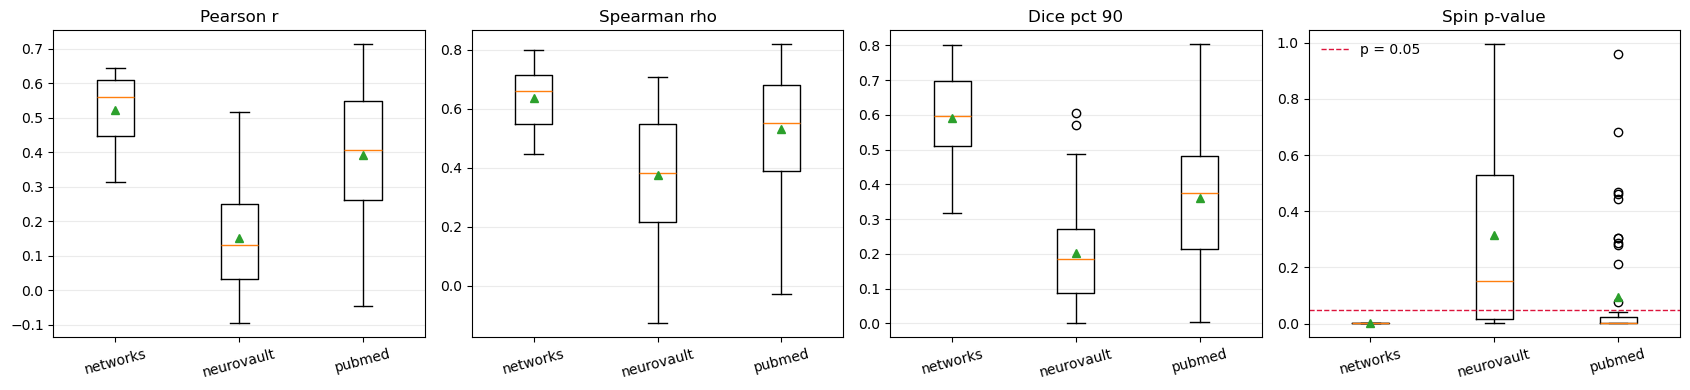

In [12]:
dice_col = f"dice_pct{DICE_PCT}"
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, metric, title in zip(axes, ["pearson_r", "spearman_rho", dice_col, "spin_p_value"], ["Pearson r", "Spearman rho", f"Dice pct {DICE_PCT}", "Spin p-value"]):
    groups = [g[metric].dropna().values for _, g in t2b_all.groupby("dataset")]
    labels = [k for k, _ in t2b_all.groupby("dataset")]
    ax.boxplot(groups, labels=labels, showmeans=True)
    if metric == "spin_p_value":
        ax.axhline(0.05, color="crimson", linestyle="--", linewidth=1, label="p = 0.05")
        ax.legend(frameon=False)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "t2b_metric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

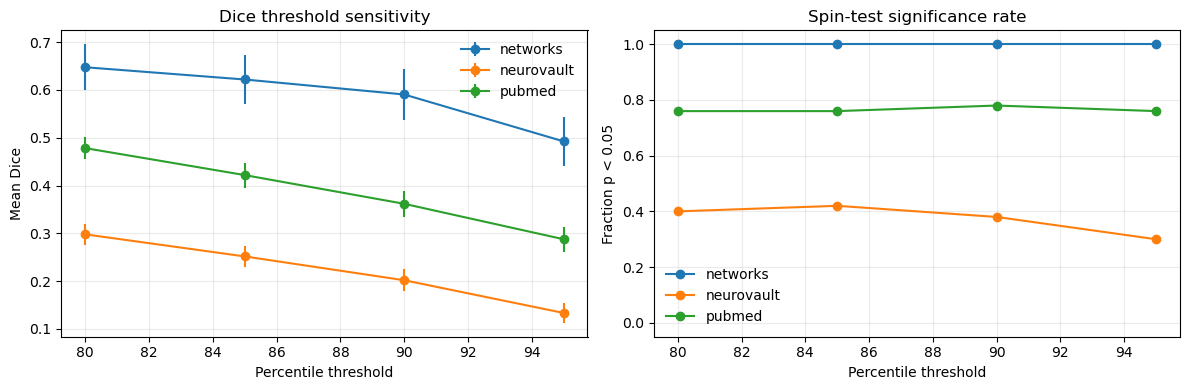

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
summary_plot = t2b_sensitivity_df.groupby(["dataset", "pct"]).agg(
    dice_mean=("dice", "mean"),
    dice_sem=("dice", lambda x: x.std() / np.sqrt(len(x))),
    sig_rate=("spin_significant", "mean"),
).reset_index()
for dataset, sub in summary_plot.groupby("dataset"):
    axes[0].errorbar(sub["pct"], sub["dice_mean"], yerr=sub["dice_sem"], marker="o", label=dataset)
    axes[1].plot(sub["pct"], sub["sig_rate"], marker="o", label=dataset)
axes[0].set_xlabel("Percentile threshold")
axes[0].set_ylabel("Mean Dice")
axes[0].set_title("Dice threshold sensitivity")
axes[1].set_xlabel("Percentile threshold")
axes[1].set_ylabel("Fraction p < 0.05")
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_title("Spin-test significance rate")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "t2b_dice_pvalue_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

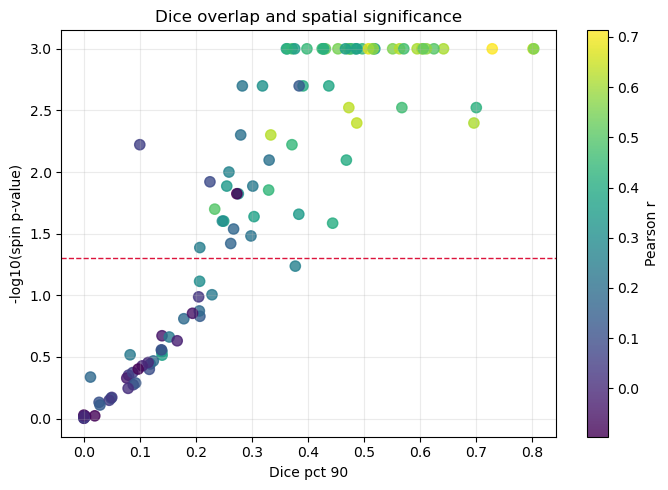

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(t2b_all[dice_col], -np.log10(t2b_all["spin_p_value"].clip(lower=1e-6)), c=t2b_all["pearson_r"], cmap="viridis", s=55, alpha=0.8)
ax.axhline(-np.log10(0.05), color="crimson", linestyle="--", linewidth=1)
ax.set_xlabel(f"Dice pct {DICE_PCT}")
ax.set_ylabel("-log10(spin p-value)")
ax.set_title("Dice overlap and spatial significance")
cb = fig.colorbar(scatter, ax=ax)
cb.set_label("Pearson r")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "t2b_dice_vs_pvalue.png", dpi=150, bbox_inches="tight")
plt.show()